# Kaggle Opdracht
## Linear Regression

### Import

In [214]:
import pandas as pd
import numpy
import sqlite3 as sql
import matplotlib.pyplot as plt
import random
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn import metrics
from sklearn.tree import plot_tree


### Inlezen van de Data

In [215]:
df = pd.read_csv("../Data/HulpmiddelenBS/student_data.csv", sep=",")
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


### Aanmaken van de Dataframe

In [216]:
df = df.loc[:, ['G3', 'G1', 'G2', 'studytime', 'failures', 'absences', 'Medu', 'Fedu']]
df

,G3,G1,G2,studytime,failures,absences,Medu,Fedu
0,6,5,6,2,0,6,4,4
1,6,5,5,2,0,4,1,1
2,10,7,8,2,3,10,1,1
3,15,15,14,3,0,2,4,2
4,10,6,10,2,0,4,3,3
...,...,...,...,...,...,...,...,...
390,9,9,9,2,2,11,2,2
391,16,14,16,1,0,3,3,1
392,7,10,8,1,3,3,1,1
393,10,11,12,1,0,0,3,2


### Horizontaal en verticaal snijden

In [217]:
X = df.drop('G3', axis=1)
y = df.loc[:, ['G3']]
X.info

<bound method DataFrame.info of      G1  G2  studytime  failures  absences  Medu  Fedu
0     5   6          2         0         6     4     4
1     5   5          2         0         4     1     1
2     7   8          2         3        10     1     1
3    15  14          3         0         2     4     2
4     6  10          2         0         4     3     3
..   ..  ..        ...       ...       ...   ...   ...
390   9   9          2         2        11     2     2
391  14  16          1         0         3     3     1
392  10   8          1         3         3     1     1
393  11  12          1         0         0     3     2
394   8   9          1         0         5     1     1

[395 rows x 7 columns]>

In [218]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.15,
    random_state=42
)

### Regressie Model

In [219]:
reg_model = linear_model.LinearRegression()
reg_model = LinearRegression().fit(X_train, y_train)
reg_model

LinearRegression()

In [220]:
y_pred = reg_model.predict(X_test)
y_pred

array([[ 6.44058031],
       [12.18127264],
       [ 3.44370371],
       [ 8.73740616],
       [ 8.02845344],
       [12.75071725],
       [18.59585228],
       [ 7.21479211],
       [ 7.46227261],
       [12.52764068],
       [14.74505886],
       [ 6.3231027 ],
       [13.95026852],
       [11.82557705],
       [14.65527949],
       [ 7.63196773],
       [ 6.31075762],
       [10.80380812],
       [14.99568266],
       [ 8.3696194 ],
       [14.12127316],
       [16.46067229],
       [15.20617735],
       [ 4.96491965],
       [ 7.94877208],
       [20.17148383],
       [10.46615985],
       [ 9.15593769],
       [17.0022198 ],
       [11.33360148],
       [ 9.24030638],
       [ 7.33948157],
       [15.08409325],
       [12.75348706],
       [ 5.99228767],
       [ 4.49795591],
       [-1.8765571 ],
       [15.00036578],
       [12.22983733],
       [ 7.78470928],
       [ 4.69314859],
       [10.27728521],
       [13.93325621],
       [ 8.00919974],
       [15.61812735],
       [ 9

In [221]:
prediction_df = pd.DataFrame(y_pred)
prediction_df = prediction_df.rename(columns = {0 : 'Predicted_G3'})
prediction_df

,Predicted_G3
0,6.440580
1,12.181273
2,3.443704
3,8.737406
4,8.028453
5,12.750717
6,18.595852
7,7.214792
8,7.462273
9,12.527641


In [222]:
y_test_prediction_merge = pd.concat([y_test.reset_index()['G3'], prediction_df], axis = 1)
y_test_prediction_merge.loc[y_test_prediction_merge['Predicted_G3'].notna(), :]

,G3,Predicted_G3
0,10,6.440580
1,12,12.181273
2,5,3.443704
3,10,8.737406
4,9,8.028453
5,13,12.750717
6,18,18.595852
7,6,7.214792
8,0,7.462273
9,14,12.527641


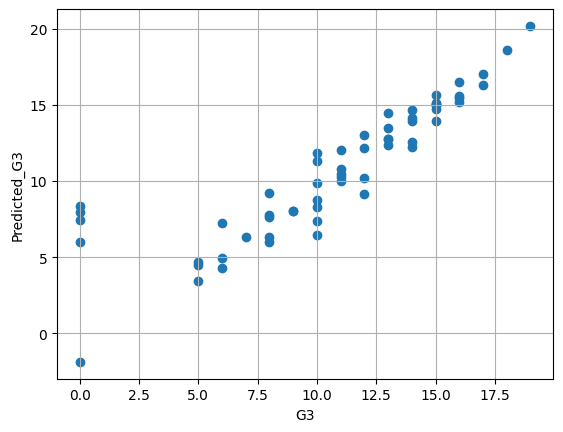

In [223]:
plt.scatter(y_test_prediction_merge['G3'], y_test_prediction_merge['Predicted_G3'])
plt.xlabel('G3')
plt.ylabel('Predicted_G3')
plt.grid(True)
plt.show()

In [224]:
mse = mean_squared_error(y_test_prediction_merge['G3'], y_test_prediction_merge['Predicted_G3'])
mae = mean_absolute_error(y_test_prediction_merge['G3'], y_test_prediction_merge['Predicted_G3'])

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

Mean Squared Error (MSE): 5.11
Mean Absolute Error (MAE): 1.37


## Desicion Tree

### Trainen van het model

In [225]:
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)
y_tree_pred = tree_model.predict(X_test)
mse_tree = mean_squared_error(y_test, y_tree_pred)
mae_tree = mean_absolute_error(y_test, y_tree_pred)
r2_tree = r2_score(y_test, y_tree_pred)

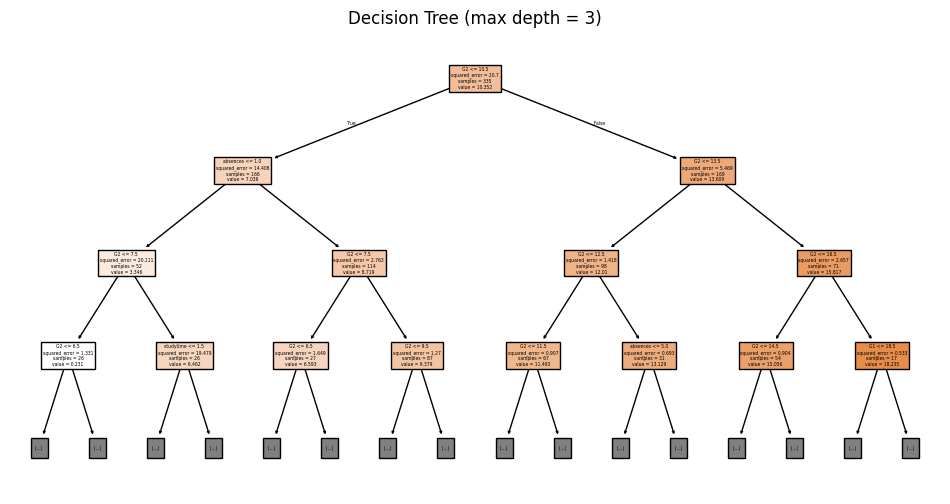

In [226]:
plt.figure(figsize=(12, 6))
plot_tree(tree_model, feature_names=X.columns, filled=True, max_depth=3)
plt.title("Decision Tree (max depth = 3)")
plt.show()

In [227]:
print(f"Mean Squared Error: {mse_tree:.2f}")
print(f"Mean Absolute Error: {mae_tree:.2f}")
print(f"R²-score: {r2_tree:.2f}")

Mean Squared Error: 5.93
Mean Absolute Error: 1.27
R²-score: 0.73
